# Behavioral syllables vs GLM-HMM engagement state

Tests whether behavioral syllables (whisking first, then licking, then paw) are more common during the GLM-HMM engaged state (state1) vs disengaged state (state2), within session.

Source: per-session files in `states_files_old` on Google Drive (`10_states_file_<eid>_<mouse>`, eid-named, ~60Hz bins, includes `trial_id` and `identifiable_states`). `paw`/`whisk`/`lick` are decoded from `identifiable_states` (a 3-digit string, one digit per modality) using the same method as `1_segmentation/neural_spike_files.ipynb`, rather than re-deriving states from the raw continuous signals (`whisker_me` etc).

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
BEH_DIR = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/states_files_old/'

## Load GLM-HMM engagement states and locate behavioral files

`states_files_old` has 3 versions per session (unprefixed, `9_`, `10_`); `10_` is used here since it was validated against `states_df` (100% contrast/block match on an example session, see `load_states.ipynb`). Filenames are `10_states_file_<eid>_<mouse_name>`, so eids are matched by prefix.

In [10]:
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
states_df = pd.read_parquet(prefix + 'GLM-HMM/merged_behavioral_and_states.pqt')
states_df['dominant_state'] = np.where(states_df['p_state1'] >= 0.5, 'state1', 'state2')

matched_sessions = sorted(set(lda['session']) & set(states_df['eid']))
print(f"GLM-HMM x LDA matched sessions: {len(matched_sessions)}")

beh_files = {}
for fname in os.listdir(BEH_DIR):
    if fname.startswith('10_states_file_'):
        eid = fname[len('10_states_file_'):].split('_')[0]
        beh_files[eid] = fname

available = [e for e in matched_sessions if e in beh_files]
print(f"Sessions with a behavioral states file: {len(available)} / {len(matched_sessions)}")

GLM-HMM x LDA matched sessions: 244
Sessions with a behavioral states file: 244 / 244


## Decode paw / whisk / lick from `identifiable_states`

`identifiable_states` is a 3-digit string per bin: digit 1 = paw (0-9), digit 2 = whisk (0/1), digit 3 = lick (0/1). Validated on an example session: `whisk=1` bins have ~5x higher `whisker_me` than `whisk=0` bins (5.21 vs 1.04), and `lick=1` bins have nonzero mean `Lick count` (0.45) vs exactly 0 for `lick=0`.

In [11]:
def load_session_behavior(eid):
    beh = pd.read_parquet(BEH_DIR + beh_files[eid])
    digits = beh['identifiable_states'].str.extract(r'(\d)(\d)(\d)').astype('Int64')
    digits.columns = ['paw', 'whisk', 'lick']
    beh[['paw', 'whisk', 'lick']] = digits
    return beh


def trial_occupancy(beh, state_col):
    """Fraction of valid (non-NaN trial_id, non-NaN state) bins in the active state, per trial_id."""
    valid = beh.dropna(subset=['trial_id', state_col]).copy()
    return valid.groupby('trial_id')[state_col].mean()


def session_engagement_comparison(eid, state_col='whisk'):
    """Per-session comparison: mean occupancy of `state_col` (0/1) during engaged (state1)
    vs disengaged (state2) trials. trial_id <-> states_df row-order alignment validated in
    load_states.ipynb (trial_id - trial_id.min() == row index for a given eid)."""
    beh = load_session_behavior(eid)

    occ = trial_occupancy(beh, state_col).rename('occupancy').reset_index()
    occ['trial_idx0'] = occ['trial_id'] - beh['trial_id'].min()

    session_states = states_df[states_df['eid'] == eid].reset_index(drop=True)
    session_states['trial_idx0'] = np.arange(len(session_states))

    merged = occ.merge(session_states[['trial_idx0', 'dominant_state']], on='trial_idx0', how='inner')
    return merged, beh

## Example session: sanity-check the decoded whisk state

           mean   count
whisk                  
0      2.383658  202940
1      7.562511   99980

NaN whisk fraction: 0.0000


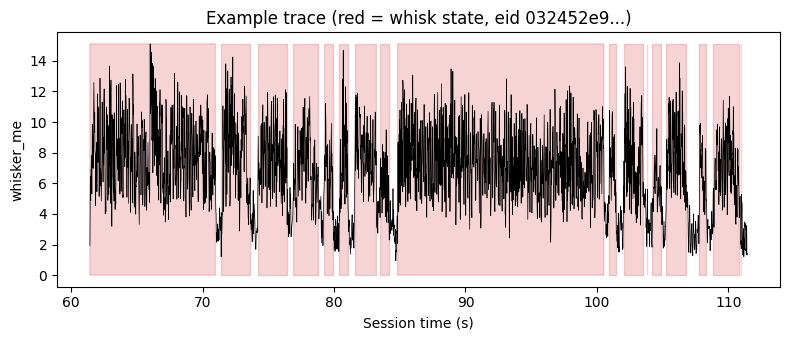

In [12]:
example_eid = available[0]
beh_example = load_session_behavior(example_eid)

print(beh_example.groupby('whisk')['whisker_me'].agg(['mean', 'count']))
print()
print(f"NaN whisk fraction: {beh_example['whisk'].isna().mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
window = slice(0, 3000)
ax.plot(beh_example['Bin'].iloc[window], beh_example['whisker_me'].iloc[window], color='k', linewidth=0.5)
ax.fill_between(beh_example['Bin'].iloc[window], 0, beh_example['whisker_me'].iloc[window].max(),
                where=(beh_example['whisk'].iloc[window] == 1), color='tab:red', alpha=0.2, step='mid')
ax.set_xlabel('Session time (s)')
ax.set_ylabel('whisker_me')
ax.set_title(f'Example trace (red = whisk state, eid {example_eid[:8]}...)')
plt.tight_layout()
plt.show()

## Example sessions: within-session engaged vs disengaged whisk occupancy

6 / 6 earlier demo sessions have a behavioral file


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_63766/4199757854.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['state1\n(engaged)', 'state2\n(disengaged)'])
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_63766/4199757854.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['state1\n(engaged)', 'state2\n(disengaged)'])
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_63766/4199757854.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['state1\n(engaged)', 'state2\n(disengaged)'])
/var/folders/nt/d2j3zp9d1

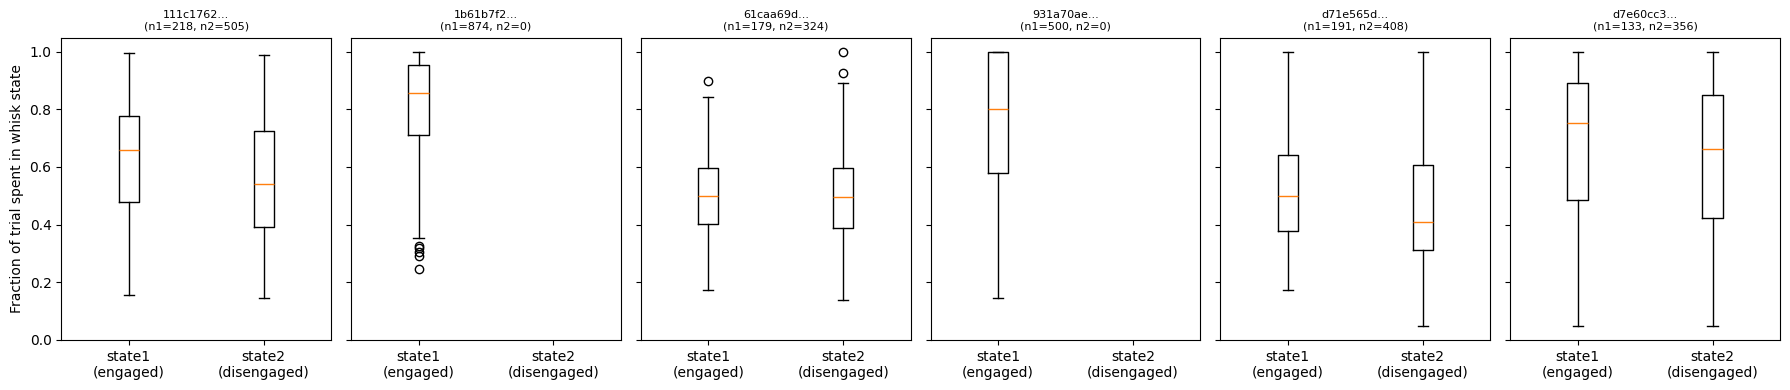

In [13]:
demo_eids = [e for e in available if e in [
    'd71e565d-4ddb-42df-849e-f99cfdeced52', '111c1762-7908-47e0-9f40-2f2ee55b6505',
    'd7e60cc3-6020-429e-a654-636c6cc677ea', '61caa69d-088b-465a-b9d0-d75341dabac6',
    '1b61b7f2-a599-4e40-abd6-3e758d2c9e25', '931a70ae-90ee-448e-bedb-9d41f3eda647',
]]
print(f"{len(demo_eids)} / 6 earlier demo sessions have a behavioral file")

fig, axes = plt.subplots(1, len(demo_eids), figsize=(3 * len(demo_eids), 4), sharey=True)
for ax, eid in zip(axes, demo_eids):
    merged, _ = session_engagement_comparison(eid)
    data = [merged.loc[merged['dominant_state'] == s, 'occupancy'] for s in ['state1', 'state2']]
    ax.boxplot(data, labels=['state1\n(engaged)', 'state2\n(disengaged)'])
    ax.set_title(f'{eid[:8]}...\n(n1={len(data[0])}, n2={len(data[1])})', fontsize=8)
axes[0].set_ylabel('Fraction of trial spent in whisk state')
plt.tight_layout()
plt.show()

## Scale to all sessions

Runs the same per-session comparison across all matched sessions (~6s/session to read from Google Drive, so this cell takes a while on first run).

In [14]:
results = []
for i, eid in enumerate(available):
    try:
        merged, _ = session_engagement_comparison(eid)
    except Exception as e:
        print(f"  Skipping {eid}: {e}")
        continue

    by_state = merged.groupby('dominant_state')['occupancy'].mean()
    if 'state1' not in by_state.index or 'state2' not in by_state.index:
        continue  # session doesn't visit both states

    results.append({
        'session': eid,
        'whisk_engaged': by_state['state1'],
        'whisk_disengaged': by_state['state2'],
        'n_state1_trials': (merged['dominant_state'] == 'state1').sum(),
        'n_state2_trials': (merged['dominant_state'] == 'state2').sum(),
    })

    if (i + 1) % 40 == 0:
        print(f"  processed {i + 1} / {len(available)}")

whisk_df = pd.DataFrame(results)
whisk_df['diff'] = whisk_df['whisk_engaged'] - whisk_df['whisk_disengaged']
print(f"\n{len(whisk_df)} / {len(available)} sessions visit both states with valid data")

  processed 40 / 244
  processed 80 / 244
  processed 120 / 244
  processed 160 / 244
  processed 200 / 244
  processed 240 / 244

241 / 244 sessions visit both states with valid data


## Aggregate result: is whisking more common when engaged or disengaged?

Wilcoxon signed-rank (engaged vs disengaged whisk occupancy): stat=3396.0, p=5.51e-25
Median whisk occupancy: engaged = 0.634, disengaged = 0.565
Sessions with MORE whisking when engaged: 83.0%


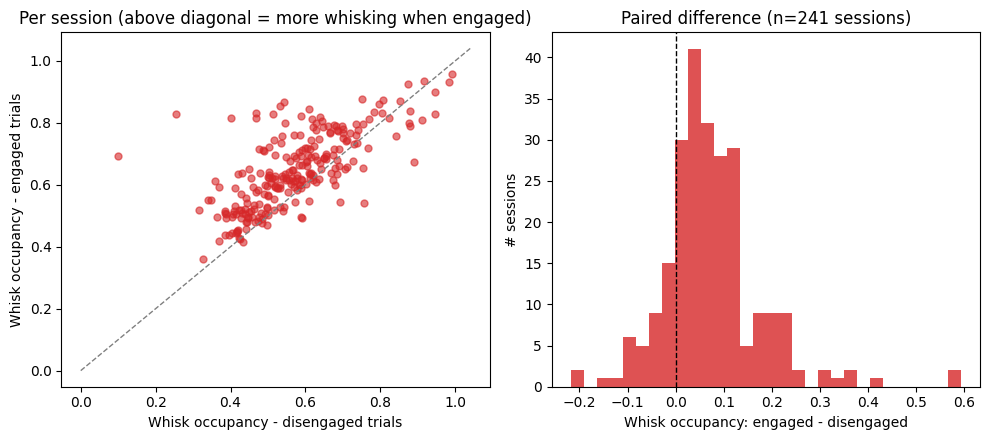

In [15]:
stat, p = wilcoxon(whisk_df['whisk_engaged'], whisk_df['whisk_disengaged'])
print(f"Wilcoxon signed-rank (engaged vs disengaged whisk occupancy): stat={stat:.1f}, p={p:.2e}")
print(f"Median whisk occupancy: engaged = {whisk_df['whisk_engaged'].median():.3f}, "
      f"disengaged = {whisk_df['whisk_disengaged'].median():.3f}")
print(f"Sessions with MORE whisking when engaged: {(whisk_df['diff'] > 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].scatter(whisk_df['whisk_disengaged'], whisk_df['whisk_engaged'], alpha=0.6, s=25, color='tab:red')
lims = [0, max(whisk_df['whisk_engaged'].max(), whisk_df['whisk_disengaged'].max()) * 1.05]
axes[0].plot(lims, lims, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Whisk occupancy - disengaged trials')
axes[0].set_ylabel('Whisk occupancy - engaged trials')
axes[0].set_title('Per session (above diagonal = more whisking when engaged)')

axes[1].hist(whisk_df['diff'], bins=30, color='tab:red', alpha=0.8)
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('Whisk occupancy: engaged - disengaged')
axes[1].set_ylabel('# sessions')
axes[1].set_title(f'Paired difference (n={len(whisk_df)} sessions)')

plt.tight_layout()
plt.show()

## Next steps: lick and paw

Same `identifiable_states` decode already gives `lick` (digit 3, binary) and `paw` (digit 1, 0-9) columns - just swap `state_col` in `session_engagement_comparison`. Lick is binary like whisk, so the same occupancy-fraction approach applies directly. Paw is multi-level (not binary), so "occupancy" needs rethinking there (e.g. fraction of time in each paw category, or fraction of time in "moving" categories vs a still baseline) - not run yet.